# Compare GenePT Results with CZ Benchmark Models (Logistic Regression)

This notebook compares our GenePT embedding results with published CZ benchmark results and our own foundation model evaluations, focusing specifically on **logistic regression** classifier performance.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set up paths
results_dir = Path('../data/cz_benchmark/results')

print("Loading results...")

Loading results...


## Load All Results

In [21]:
# Note: We previously loaded CZ published benchmark results here,
# but now we're focusing only on our own implementations for direct comparison.
# This allows us to compare GenePT, foundation models, and their combinations
# using consistent methodology and logistic regression classifier.

print("Skipping CZ published results - focusing on our implementations only")

Skipping CZ published results - focusing on our implementations only


In [22]:
# Placeholder - previously filtered CZ published results
# Now using only our own implementations

## Load Our Results (Logistic Regression Only)

In [23]:
# Load our foundation model only results (scGPT and Transcriptformer alone)
foundation_results = pd.read_csv(results_dir / 'cz_benchmarks_foundation_only_results.csv')

# Load our combined results (GenePT alone and GenePT + foundation models)
combined_results = pd.read_csv(results_dir / 'cz_benchmarks_results.csv')

print(f"Loaded {len(foundation_results)} foundation-only results")
print(f"Loaded {len(combined_results)} combined results")

# Combine all our results
our_results = pd.concat([foundation_results, combined_results], ignore_index=True)

# Filter for successful results only
our_results = our_results[our_results['status'] == 'success'].copy()

print(f"\nTotal successful results: {len(our_results)}")
print(f"Embedding types: {sorted(our_results['embedding'].unique())}")
print(f"Tissues: {sorted(our_results['tissue'].unique())}")

print(f"\n=== Sample of our LR results ===")
print(our_results[['tissue', 'embedding', 'mean_fold_accuracy_lr', 'mean_fold_f1_lr']].to_string(index=False))

Loaded 10 foundation-only results
Loaded 15 combined results

Total successful results: 25
Embedding types: ['genept_1024d', 'genept_scgpt', 'genept_transcriptformer', 'scgpt', 'transcriptformer']
Tissues: ['Blood', 'Bone_Marrow', 'Lung', 'Mammary', 'Thymus']

=== Sample of our LR results ===
     tissue               embedding  mean_fold_accuracy_lr  mean_fold_f1_lr
      Blood                   scgpt               0.897009         0.808316
      Blood        transcriptformer               0.906172         0.824322
Bone_Marrow                   scgpt               0.864773         0.726611
Bone_Marrow        transcriptformer               0.865520         0.738101
       Lung                   scgpt               0.930896         0.823247
       Lung        transcriptformer               0.938498         0.832778
    Mammary                   scgpt               0.992931         0.884250
    Mammary        transcriptformer               0.987643         0.907243
     Thymus           

In [34]:
# Create comprehensive table: All metrics, all classifiers, averaged over tissues
print("\n" + "="*80)
print("COMPREHENSIVE PERFORMANCE TABLE")
print("All Metrics × All Classifiers × All Models (Averaged Over Tissues)")
print("="*80)

# Model mapping with desired order
model_mapping = {
    'genept_1024d': 'GenePT',
    'scgpt': 'scGPT',
    'genept_scgpt': 'GenePT + scGPT',
    'transcriptformer': 'Transcriptformer',
    'genept_transcriptformer': 'GenePT + Transcriptformer'
}

model_order = ['GenePT', 'scGPT', 'GenePT + scGPT', 'Transcriptformer', 'GenePT + Transcriptformer']
classifiers = ['lr', 'knn', 'rf']
metrics = ['accuracy', 'f1', 'precision', 'recall']

# Build comprehensive dataframe
results_list = []

for _, row in our_results.iterrows():
    model_name = model_mapping[row['embedding']]
    
    for classifier in classifiers:
        result_row = {'Model': model_name, 'Classifier': classifier}
        
        for metric in metrics:
            col_name = f'mean_fold_{metric}_{classifier}'
            if col_name in row:
                result_row[metric.capitalize()] = row[col_name]
        
        results_list.append(result_row)

comprehensive_df = pd.DataFrame(results_list)

# Average over tissues (group by Model and Classifier)
comprehensive_summary = comprehensive_df.groupby(['Model', 'Classifier']).mean().reset_index()

# Sort by model order and classifier
comprehensive_summary['Model'] = pd.Categorical(comprehensive_summary['Model'], categories=model_order, ordered=True)
comprehensive_summary = comprehensive_summary.sort_values(['Model', 'Classifier'])

# Create a nicely formatted table
print("\n" + "-"*80)
print(f"{'Model':<25} {'Classifier':<10} {'Accuracy':>10} {'F1':>10} {'Precision':>10} {'Recall':>10}")
print("-"*80)

for _, row in comprehensive_summary.iterrows():
    print(f"{row['Model']:<25} {row['Classifier']:<10} "
          f"{row['Accuracy']:>10.4f} {row['F1']:>10.4f} "
          f"{row['Precision']:>10.4f} {row['Recall']:>10.4f}")

print("-"*80)

# Also create pivot tables for each metric
print("\n=== ACCURACY by Model and Classifier ===")
accuracy_table = comprehensive_summary.pivot_table(index='Model', columns='Classifier', values='Accuracy')
print(accuracy_table.to_string())

print("\n=== F1 SCORE by Model and Classifier ===")
f1_table = comprehensive_summary.pivot_table(index='Model', columns='Classifier', values='F1')
print(f1_table.to_string())

print("\n=== PRECISION by Model and Classifier ===")
precision_table = comprehensive_summary.pivot_table(index='Model', columns='Classifier', values='Precision')
print(precision_table.to_string())

print("\n=== RECALL by Model and Classifier ===")
recall_table = comprehensive_summary.pivot_table(index='Model', columns='Classifier', values='Recall')
print(recall_table.to_string())

# Save the comprehensive summary
comprehensive_summary.to_csv(results_dir / 'comprehensive_performance_all_classifiers.csv', index=False)
print(f"\nSaved comprehensive table to: {results_dir / 'comprehensive_performance_all_classifiers.csv'}")


COMPREHENSIVE PERFORMANCE TABLE
All Metrics × All Classifiers × All Models (Averaged Over Tissues)

--------------------------------------------------------------------------------
Model                     Classifier   Accuracy         F1  Precision     Recall
--------------------------------------------------------------------------------
GenePT                    knn            0.8695     0.7208     0.7637     0.7055
GenePT                    lr             0.9104     0.8007     0.8172     0.7948
GenePT                    rf             0.8835     0.7309     0.7786     0.7137
scGPT                     knn            0.9043     0.7964     0.8238     0.7851
scGPT                     lr             0.9147     0.8219     0.8304     0.8209
scGPT                     rf             0.9154     0.7976     0.8353     0.7870
GenePT + scGPT            knn            0.9052     0.7899     0.8175     0.7781
GenePT + scGPT            lr             0.9196     0.8270     0.8353     0.8255
GenePT +

/var/folders/m4/s7psztg92q5_fkd62dqt3qw40000gn/T/ipykernel_85182/214667065.py:59: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  accuracy_table = comprehensive_summary.pivot_table(index='Model', columns='Classifier', values='Accuracy')
/var/folders/m4/s7psztg92q5_fkd62dqt3qw40000gn/T/ipykernel_85182/214667065.py:63: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  f1_table = comprehensive_summary.pivot_table(index='Model', columns='Classifier', values='F1')
/var/folders/m4/s7psztg92q5_fkd62dqt3qw40000gn/T/ipykernel_85182/214667065.py:67: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Spe

## Prepare Comparison Data (Logistic Regression)

In [30]:
# Create unified comparison dataframe (LR metrics only)
# Only using our results - excluding CZ published benchmarks
comparison_data = []

# Model mapping - using cleaner names
model_mapping = {
    'genept_1024d': 'GenePT',
    'scgpt': 'scGPT',
    'genept_scgpt': 'GenePT + scGPT',
    'transcriptformer': 'Transcriptformer',
    'genept_transcriptformer': 'GenePT + Transcriptformer'
}

for _, row in our_results.iterrows():
    comparison_data.append({
        'tissue': row['tissue'],
        'model': model_mapping[row['embedding']],
        'accuracy': row['mean_fold_accuracy_lr'],
        'f1': row['mean_fold_f1_lr'],
        'precision': row['mean_fold_precision_lr'],
        'recall': row['mean_fold_recall_lr']
    })

comparison_df = pd.DataFrame(comparison_data)

# Sort for better display
comparison_df = comparison_df.sort_values(['tissue', 'model'])

print("\n=== Combined Comparison Data (Logistic Regression) ===")
print(comparison_df[['tissue', 'model', 'accuracy', 'f1', 'precision', 'recall']].to_string(index=False))


=== Combined Comparison Data (Logistic Regression) ===
     tissue                     model  accuracy       f1  precision   recall
      Blood                    GenePT  0.892680 0.790933   0.811816 0.781285
      Blood GenePT + Transcriptformer  0.907690 0.821823   0.829881 0.819996
      Blood            GenePT + scGPT  0.904430 0.812840   0.819821 0.811644
      Blood          Transcriptformer  0.906172 0.824322   0.829776 0.824269
      Blood                     scGPT  0.897009 0.808316   0.819235 0.806631
Bone_Marrow                    GenePT  0.852696 0.671279   0.709001 0.658028
Bone_Marrow GenePT + Transcriptformer  0.866765 0.742452   0.765814 0.733569
Bone_Marrow            GenePT + scGPT  0.864649 0.729410   0.748627 0.727143
Bone_Marrow          Transcriptformer  0.865520 0.738101   0.758096 0.733537
Bone_Marrow                     scGPT  0.864773 0.726611   0.742000 0.726055
       Lung                    GenePT  0.930639 0.811087   0.820821 0.807378
       Lung GenePT +

## Performance Tables (Logistic Regression)

In [31]:
# Create pivot tables for easy comparison
print("\n=== Accuracy (Logistic Regression) by Model and Tissue ===")
accuracy_pivot = comparison_df.pivot_table(
    index='tissue',
    columns='model',
    values='accuracy',
    aggfunc='mean'
)

# Order columns: GenePT, scGPT, GenePT+scGPT, Transcriptformer, GenePT+Transcriptformer
column_order = [
    'GenePT',
    'scGPT',
    'GenePT + scGPT',
    'Transcriptformer',
    'GenePT + Transcriptformer'
]
accuracy_pivot = accuracy_pivot[[col for col in column_order if col in accuracy_pivot.columns]]

print(accuracy_pivot.to_string())

print("\n=== F1 Score (Logistic Regression) by Model and Tissue ===")
f1_pivot = comparison_df.pivot_table(
    index='tissue',
    columns='model',
    values='f1',
    aggfunc='mean'
)
f1_pivot = f1_pivot[[col for col in column_order if col in f1_pivot.columns]]

print(f1_pivot.to_string())

print("\n=== Precision (Logistic Regression) by Model and Tissue ===")
precision_pivot = comparison_df.pivot_table(
    index='tissue',
    columns='model',
    values='precision',
    aggfunc='mean'
)
precision_pivot = precision_pivot[[col for col in column_order if col in precision_pivot.columns]]

print(precision_pivot.to_string())

print("\n=== Recall (Logistic Regression) by Model and Tissue ===")
recall_pivot = comparison_df.pivot_table(
    index='tissue',
    columns='model',
    values='recall',
    aggfunc='mean'
)
recall_pivot = recall_pivot[[col for col in column_order if col in recall_pivot.columns]]

print(recall_pivot.to_string())

# Calculate mean performance across tissues
print("\n=== Mean Performance Across All Tissues ===")
print("\nAccuracy:")
print(accuracy_pivot.mean().to_string())
print("\nF1 Score:")
print(f1_pivot.mean().to_string())
print("\nPrecision:")
print(precision_pivot.mean().to_string())
print("\nRecall:")
print(recall_pivot.mean().to_string())


=== Accuracy (Logistic Regression) by Model and Tissue ===
model          GenePT     scGPT  GenePT + scGPT  Transcriptformer  GenePT + Transcriptformer
tissue                                                                                      
Blood        0.892680  0.897009        0.904430          0.906172                   0.907690
Bone_Marrow  0.852696  0.864773        0.864649          0.865520                   0.866765
Lung         0.930639  0.930896        0.938412          0.938498                   0.941830
Mammary      0.992284  0.992931        0.993633          0.987643                   0.993525
Thymus       0.883676  0.888116        0.896993          0.915053                   0.914245

=== F1 Score (Logistic Regression) by Model and Tissue ===
model          GenePT     scGPT  GenePT + scGPT  Transcriptformer  GenePT + Transcriptformer
tissue                                                                                      
Blood        0.790933  0.808316        0.81

In [32]:
# Calculate improvements
print("\n" + "="*80)
print("IMPROVEMENT ANALYSIS (Logistic Regression)")
print("="*80)

# GenePT + Foundation Model vs Foundation Model alone
print("\n=== Improvement from Adding GenePT to Foundation Models ===")

if 'scGPT' in accuracy_pivot.columns and 'GenePT + scGPT' in accuracy_pivot.columns:
    scgpt_improvement = accuracy_pivot['GenePT + scGPT'] - accuracy_pivot['scGPT']
    print("\nAccuracy Improvement: GenePT + scGPT vs scGPT alone")
    print(scgpt_improvement.to_string())
    print(f"Mean improvement: {scgpt_improvement.mean():.4f} ({scgpt_improvement.mean()*100:.2f}%)")

if 'Transcriptformer' in accuracy_pivot.columns and 'GenePT + Transcriptformer' in accuracy_pivot.columns:
    tf_improvement = accuracy_pivot['GenePT + Transcriptformer'] - accuracy_pivot['Transcriptformer']
    print("\nAccuracy Improvement: GenePT + Transcriptformer vs Transcriptformer alone")
    print(tf_improvement.to_string())
    print(f"Mean improvement: {tf_improvement.mean():.4f} ({tf_improvement.mean()*100:.2f}%)")

# F1 improvements
print("\n=== F1 Score Improvement from Adding GenePT ===")

if 'scGPT' in f1_pivot.columns and 'GenePT + scGPT' in f1_pivot.columns:
    scgpt_f1_improvement = f1_pivot['GenePT + scGPT'] - f1_pivot['scGPT']
    print("\nF1 Improvement: GenePT + scGPT vs scGPT alone")
    print(scgpt_f1_improvement.to_string())
    print(f"Mean improvement: {scgpt_f1_improvement.mean():.4f} ({scgpt_f1_improvement.mean()*100:.2f}%)")

if 'Transcriptformer' in f1_pivot.columns and 'GenePT + Transcriptformer' in f1_pivot.columns:
    tf_f1_improvement = f1_pivot['GenePT + Transcriptformer'] - f1_pivot['Transcriptformer']
    print("\nF1 Improvement: GenePT + Transcriptformer vs Transcriptformer alone")
    print(tf_f1_improvement.to_string())
    print(f"Mean improvement: {tf_f1_improvement.mean():.4f} ({tf_f1_improvement.mean()*100:.2f}%)")

# Foundation Model vs GenePT alone
print("\n=== Foundation Models vs GenePT Alone ===")

if 'GenePT' in accuracy_pivot.columns and 'scGPT' in accuracy_pivot.columns:
    scgpt_vs_genept = accuracy_pivot['scGPT'] - accuracy_pivot['GenePT']
    print("\nAccuracy Difference: scGPT vs GenePT")
    print(scgpt_vs_genept.to_string())
    print(f"Mean difference: {scgpt_vs_genept.mean():.4f} ({scgpt_vs_genept.mean()*100:.2f}%)")

if 'GenePT' in accuracy_pivot.columns and 'Transcriptformer' in accuracy_pivot.columns:
    tf_vs_genept = accuracy_pivot['Transcriptformer'] - accuracy_pivot['GenePT']
    print("\nAccuracy Difference: Transcriptformer vs GenePT")
    print(tf_vs_genept.to_string())
    print(f"Mean difference: {tf_vs_genept.mean():.4f} ({tf_vs_genept.mean()*100:.2f}%)")


IMPROVEMENT ANALYSIS (Logistic Regression)

=== Improvement from Adding GenePT to Foundation Models ===

Accuracy Improvement: GenePT + scGPT vs scGPT alone
tissue
Blood          0.007421
Bone_Marrow   -0.000124
Lung           0.007516
Mammary        0.000701
Thymus         0.008877
Mean improvement: 0.0049 (0.49%)

Accuracy Improvement: GenePT + Transcriptformer vs Transcriptformer alone
tissue
Blood          0.001518
Bone_Marrow    0.001244
Lung           0.003332
Mammary        0.005882
Thymus        -0.000808
Mean improvement: 0.0022 (0.22%)

=== F1 Score Improvement from Adding GenePT ===

F1 Improvement: GenePT + scGPT vs scGPT alone
tissue
Blood          0.004524
Bone_Marrow    0.002800
Lung           0.003324
Mammary        0.007999
Thymus         0.006785
Mean improvement: 0.0051 (0.51%)

F1 Improvement: GenePT + Transcriptformer vs Transcriptformer alone
tissue
Blood         -0.002499
Bone_Marrow    0.004352
Lung          -0.000566
Mammary        0.005461
Thymus         0.00

## Visualizations


Saved comparison figure to: ../data/cz_benchmark/results/genept_foundation_comparison_lr.png


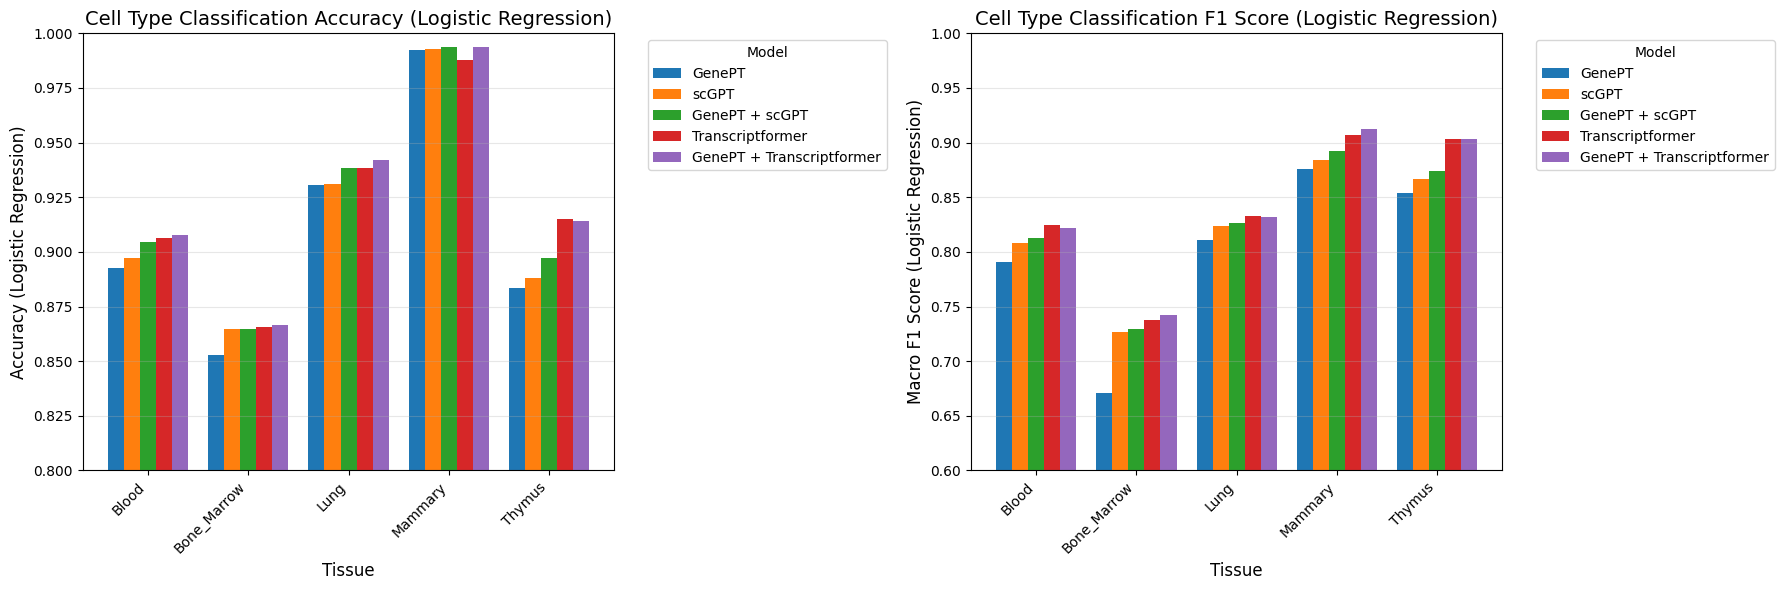

In [33]:
# Create comprehensive comparison plot (LR only)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Accuracy comparison
accuracy_pivot.plot(kind='bar', ax=ax1, width=0.8, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
ax1.set_xlabel('Tissue', fontsize=12)
ax1.set_ylabel('Accuracy (Logistic Regression)', fontsize=12)
ax1.set_title('Cell Type Classification Accuracy (Logistic Regression)', fontsize=14)
ax1.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0.80, 1.0])

# Plot 2: F1 comparison
f1_pivot.plot(kind='bar', ax=ax2, width=0.8, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
ax2.set_xlabel('Tissue', fontsize=12)
ax2.set_ylabel('Macro F1 Score (Logistic Regression)', fontsize=12)
ax2.set_title('Cell Type Classification F1 Score (Logistic Regression)', fontsize=14)
ax2.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0.60, 1.0])

plt.tight_layout()

# Save figure
fig_path = results_dir / 'genept_foundation_comparison_lr.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\nSaved comparison figure to: {fig_path}")

plt.show()


Saved improvement heatmap to: ../data/cz_benchmark/results/genept_improvement_heatmap_lr.png


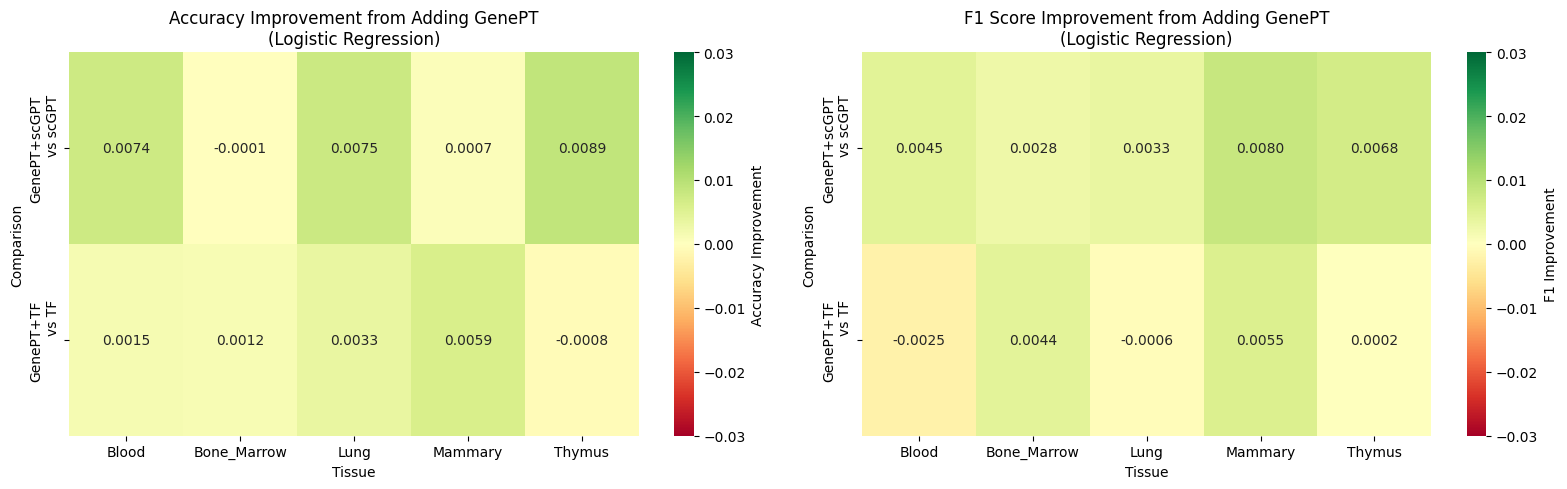

In [28]:
# Create improvement heatmap
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Accuracy improvements
if 'scGPT' in accuracy_pivot.columns and 'GenePT + scGPT' in accuracy_pivot.columns:
    improvements_acc = pd.DataFrame({
        'GenePT+scGPT\nvs scGPT': accuracy_pivot['GenePT + scGPT'] - accuracy_pivot['scGPT'],
        'GenePT+TF\nvs TF': accuracy_pivot['GenePT + Transcriptformer'] - accuracy_pivot['Transcriptformer']
    })
    
    sns.heatmap(improvements_acc.T, annot=True, fmt='.4f', cmap='RdYlGn', center=0,
                cbar_kws={'label': 'Accuracy Improvement'}, ax=ax1, vmin=-0.03, vmax=0.03)
    ax1.set_title('Accuracy Improvement from Adding GenePT\n(Logistic Regression)', fontsize=12)
    ax1.set_xlabel('Tissue', fontsize=10)
    ax1.set_ylabel('Comparison', fontsize=10)

# F1 improvements
if 'scGPT' in f1_pivot.columns and 'GenePT + scGPT' in f1_pivot.columns:
    improvements_f1 = pd.DataFrame({
        'GenePT+scGPT\nvs scGPT': f1_pivot['GenePT + scGPT'] - f1_pivot['scGPT'],
        'GenePT+TF\nvs TF': f1_pivot['GenePT + Transcriptformer'] - f1_pivot['Transcriptformer']
    })
    
    sns.heatmap(improvements_f1.T, annot=True, fmt='.4f', cmap='RdYlGn', center=0,
                cbar_kws={'label': 'F1 Improvement'}, ax=ax2, vmin=-0.03, vmax=0.03)
    ax2.set_title('F1 Score Improvement from Adding GenePT\n(Logistic Regression)', fontsize=12)
    ax2.set_xlabel('Tissue', fontsize=10)
    ax2.set_ylabel('Comparison', fontsize=10)

plt.tight_layout()

# Save figure
fig_path = results_dir / 'genept_improvement_heatmap_lr.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\nSaved improvement heatmap to: {fig_path}")

plt.show()

## Save Results

In [29]:
# Save combined comparison table
comparison_df.to_csv(results_dir / 'foundation_comparison_lr.csv', index=False)
print(f"Saved comparison results to: {results_dir / 'foundation_comparison_lr.csv'}")

# Save pivot tables
accuracy_pivot.to_csv(results_dir / 'accuracy_comparison_table_lr.csv')
f1_pivot.to_csv(results_dir / 'f1_comparison_table_lr.csv')
precision_pivot.to_csv(results_dir / 'precision_comparison_table_lr.csv')
recall_pivot.to_csv(results_dir / 'recall_comparison_table_lr.csv')
print(f"Saved metric pivot tables to results directory")

print("\n" + "="*80)
print("COMPARISON ANALYSIS COMPLETE (Logistic Regression)")
print("="*80)
print(f"\nAnalyzed {len(comparison_df)} results across:")
print(f"  - {len(accuracy_pivot.columns)} models")
print(f"  - {len(accuracy_pivot.index)} tissues")
print(f"\nModel order: GenePT → scGPT → GenePT+scGPT → Transcriptformer → GenePT+Transcriptformer")
print(f"All results use Logistic Regression classifier")

Saved comparison results to: ../data/cz_benchmark/results/foundation_comparison_lr.csv
Saved metric pivot tables to results directory

COMPARISON ANALYSIS COMPLETE (Logistic Regression)

Analyzed 25 results across:
  - 5 models
  - 5 tissues

Model order: GenePT → scGPT → GenePT+scGPT → Transcriptformer → GenePT+Transcriptformer
All results use Logistic Regression classifier
